# Clinical text to medical specialty

This notebook completes **task (a)**: inspect and repair the supplied files, train and validate specialty classifiers, then predict one label per row of `test_no_labels.csv` into `results.txt`.

The source files use semicolons and contain malformed physical records. The data-quality review also checks whether input fields reveal the target label. That issue is reported separately from language-model performance.


## 1. Load and structurally repair the files

The training data has occasional records split across physical lines. Join only the known overflow pattern (a line ending in `";;;` followed by a line that does not start a new known label), then parse each record independently. The unlabeled test file is parsed as four text columns and its physical line breaks are truncated, matching the supplied file's record convention.


In [1]:
import csv
import html
import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

LABELS = {
    'Surgery', 'Cardiovascular-Pulmonary', 'Orthopedic', 'Radiology',
    'General Medicine', 'Gastroenterology', 'Neurology', 'Obstetrics-Gynecology',
    'Neurosurgery', 'Ophthalmology', 'Psychiatry-Psychology', 'Dermatology',
}
CLASS_ORDER = sorted(LABELS)
ALL_COLS = ['medical_specialty', 'description', 'sample_name', 'transcription', 'keywords']
TEXT_COLS = ALL_COLS[1:]
RECORD_START = re.compile(r'^(' + '|'.join(map(re.escape, LABELS)) + r');')


def load_train(path):
    with open(path, encoding='utf-8-sig', newline='') as source:
        lines = source.read().splitlines()
    records = [line for line in lines[1:] if line.strip()]
    repaired = []
    for line in records:
        continuation = repaired and repaired[-1].endswith('";;;') and not RECORD_START.match(line)
        if continuation:
            head = repaired.pop()[:-4]
            line = head + line.lstrip('"').rstrip('";') + ';'
        repaired.append(line)

    rows, bad_rows = [], []
    for row_number, record in enumerate(repaired):
        fields = next(csv.reader([record], delimiter=';'))
        if any(field.strip() for field in fields[len(ALL_COLS):]):
            bad_rows.append(row_number)
        fields = (fields + [''] * len(ALL_COLS))[:len(ALL_COLS)]
        rows.append([field.replace('""', '"').strip() for field in fields])

    frame = pd.DataFrame(rows, columns=ALL_COLS).replace('', pd.NA)
    if bad_rows:
        raise ValueError(f'Unexpected non-empty extra fields in repaired rows: {bad_rows[:10]}')
    return frame


def load_test(path):
    frame = pd.read_csv(path, sep=';', header=None, names=TEXT_COLS, encoding='utf-8-sig')
    for column in TEXT_COLS:
        frame[column] = frame[column].map(
            lambda value: str(value).splitlines()[0].strip() if pd.notna(value) else pd.NA
        )
    return frame


train_raw = load_train(Path('train.csv'))
test_raw = load_test(Path('test_no_labels.csv'))
print(f'Training rows: {len(train_raw):,}; test rows: {len(test_raw):,}')
print('Training labels recovered:', sorted(train_raw['medical_specialty'].dropna().unique()))
print('Unexpected labels:', sorted(set(train_raw['medical_specialty'].dropna()) - LABELS))


Training rows: 2,669; test rows: 409
Training labels recovered: ['Cardiovascular-Pulmonary', 'Dermatology', 'Gastroenterology', 'General Medicine', 'Neurology', 'Neurosurgery', 'Obstetrics-Gynecology', 'Ophthalmology', 'Orthopedic', 'Psychiatry-Psychology', 'Radiology', 'Surgery']
Unexpected labels: []


## 2. Understand the data before modeling

Check record counts, class balance, missingness, field lengths, representative cases, duplicates, and label conflicts. These checks matter because the most common class is much larger than several specialties, and identical reports can carry different labels.


In [2]:
print('Train shape:', train_raw.shape, '| test shape:', test_raw.shape)
print('Duplicate complete training rows:', int(train_raw.duplicated().sum()))
print('\nMissing values (training):')
print(train_raw.isna().sum().to_string())
print('\nMissing values (test):')
print(test_raw.isna().sum().to_string())

word_counts = pd.DataFrame({
    column: train_raw[column].fillna('').astype(str).str.split().str.len()
    for column in TEXT_COLS
})
length_summary = pd.DataFrame({
    'missing %': (train_raw[TEXT_COLS].isna().mean() * 100).round(1),
    'median words': word_counts.median().astype(int),
    'mean words': word_counts.mean().round(1),
    'max words': word_counts.max().astype(int),
})
print('\nText-field lengths:')
print(length_summary)


Train shape: (2669, 5) | test shape: (409, 4)
Duplicate complete training rows: 0

Missing values (training):
medical_specialty      0
description            1
sample_name            7
transcription         31
keywords             450

Missing values (test):
description       1
sample_name       9
transcription    11
keywords         83

Text-field lengths:
               missing %  median words  mean words  max words
description          0.0            16        18.9         76
sample_name          0.3             4         3.8          8
transcription        1.2           386       451.7       2454
keywords            16.9            19        22.6        118


                          records  share %
medical_specialty                         
Cardiovascular-Pulmonary      309     11.6
Dermatology                    25      0.9
Gastroenterology              195      7.3
General Medicine              212      7.9
Neurology                     184      6.9
Neurosurgery                   79      3.0
Obstetrics-Gynecology         136      5.1
Ophthalmology                  73      2.7
Orthopedic                    300     11.2
Psychiatry-Psychology          41      1.5
Radiology                     222      8.3
Surgery                       893     33.5

Largest/smallest class ratio: 35.7:1
Always-Surgery accuracy: 33.5%


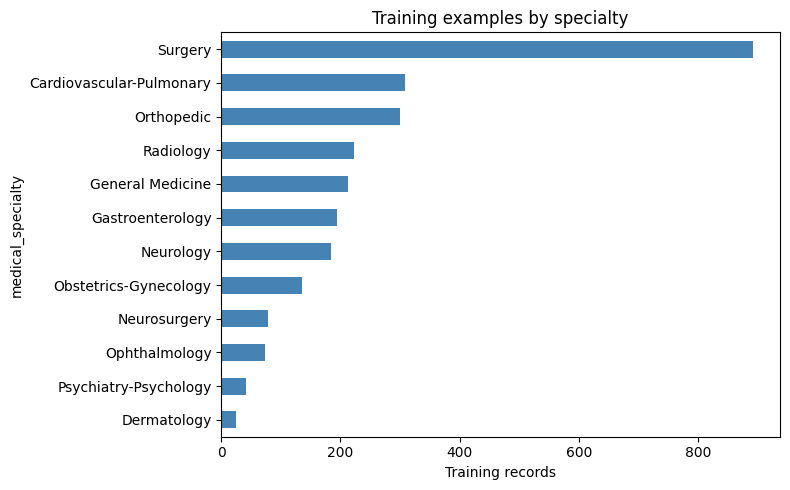

In [3]:
class_counts = train_raw['medical_specialty'].value_counts().reindex(CLASS_ORDER, fill_value=0)
class_summary = pd.DataFrame({
    'records': class_counts,
    'share %': (class_counts / len(train_raw) * 100).round(1),
})
print(class_summary.to_string())
print(f'\nLargest/smallest class ratio: {class_counts.max() / class_counts.min():.1f}:1')
print(f'Always-Surgery accuracy: {class_counts.max() / len(train_raw):.1%}')
ax = class_counts.sort_values().plot.barh(figsize=(8, 5), color='steelblue')
ax.set_xlabel('Training records')
ax.set_title('Training examples by specialty')
plt.tight_layout()
plt.show()


In [4]:
print('One example per specialty (text clipped for readability):')
examples = train_raw.groupby('medical_specialty', sort=True).head(1)
for _, row in examples.iterrows():
    print(f"\n[{row['medical_specialty']}] sample={str(row['sample_name'])[:70]!r}")
    print(' description:', str(row['description'])[:180])
    print(' keywords:   ', str(row['keywords'])[:130])

print('\nDuplicate-text conflicts:')
for column in ['description', 'sample_name', 'transcription']:
    subset = train_raw.dropna(subset=[column])
    grouped = subset.groupby(column)['medical_specialty']
    label_counts = grouped.nunique()
    conflicting = label_counts[label_counts > 1].index
    affected = int(grouped.size().reindex(conflicting).sum()) if len(conflicting) else 0
    print(f'{column}: {len(conflicting):,} repeated text values have multiple labels; {affected:,} rows affected')


One example per specialty (text clipped for readability):

[Cardiovascular-Pulmonary] sample='Chest Pain - Cardiac Consult'
 description: Chest pain, possible syncopal spells.  She has been having multiple cardiovascular complaints including chest pains, which feel like cramps and sometimes like a dull ache, which wi
 keywords:    cardiovascular / pulmonary, chest pain, syncopal, echocardiogram, ekg, cardiac etiology, syncopal spells, rhythm, flexeril, cardia

[Gastroenterology] sample='Melena - ICU Followup'
 description: Reason for ICU followup today is acute anemia secondary to upper GI bleeding with melena with dropping hemoglobin from 11 to 8, status post transfusion of 2 units PRBCs with EGD pe
 keywords:    gastroenterology, anemia, gi bleeding, hemoglobin, ulcerative, esophagitis, obstructive pulmonary disease, icu followup, infection

[Psychiatry-Psychology] sample='Neuropsychological Evaluation - 5'
 description: The patient comes in for a neurology consultation regarding her

## 3. Audit the keyword field for target leakage

Before text cleaning, check whether a keyword list begins with an exact specialty name (including `obstetrics / gynecology`). This is suspicious because it directly encodes the answer. Keep the marker as a separate, explicitly disclosed rule for the supplied competition output; remove it from text features so the fallback model cannot learn from it. The marker-assisted validation score must not be interpreted as text-only generalization.


In [5]:
LABEL_FROM_PREFIX = {label.lower(): label for label in LABELS}
LABEL_FROM_PREFIX.update({label.lower().replace('-', ' / '): label for label in LABELS})


def label_marker(row):
    # Some malformed test rows have the keyword list shifted into description or transcription.
    for column in ['keywords', 'description', 'transcription']:
        value = row[column]
        if pd.notna(value):
            first_term = str(value).split(',', 1)[0].strip().lower()
            if first_term in LABEL_FROM_PREFIX:
                return LABEL_FROM_PREFIX[first_term]
    return None


train_marker = train_raw.apply(label_marker, axis=1)
test_marker = test_raw.apply(label_marker, axis=1)
marker_rows = train_marker.notna()
marker_matches = int((train_marker[marker_rows] == train_raw.loc[marker_rows, 'medical_specialty']).sum())
marker_mismatches = int(marker_rows.sum()) - marker_matches
print(f'Train rows with exact specialty marker: {int(marker_rows.sum()):,}/{len(train_raw):,} ({marker_rows.mean():.1%})')
print(f'Markers matching their training labels: {marker_matches:,}; mismatches: {marker_mismatches:,}')
print(f'Test rows with exact marker in any text field: {int(test_marker.notna().sum()):,}/{len(test_raw):,} ({test_marker.notna().mean():.1%})')
print('Test marker locations:', {
    column: int(test_raw[column].fillna('').astype(str).str.match(
        r'^\s*(?:' + '|'.join(re.escape(x) for x in LABEL_FROM_PREFIX) + r')\s*,', case=False
    ).sum()) for column in ['keywords', 'description', 'transcription']
})
if marker_mismatches:
    raise ValueError('Specialty prefix does not match the training label; review the leakage rule.')


Train rows with exact specialty marker: 2,219/2,669 (83.1%)
Markers matching their training labels: 2,219; mismatches: 0
Test rows with exact marker in any text field: 325/409 (79.5%)
Test marker locations: {'keywords': 320, 'description': 4, 'transcription': 1}


## 4. Clean and normalize the text

Normalize Unicode and HTML entities, collapse whitespace, remove an exact leading specialty marker from any text field, and cut the appended `NOTE` disclaimer from keywords. Preserve clinically meaningful words, abbreviations, numbers, and punctuation rather than aggressively stripping medical terminology.


In [6]:
PREFIX_PATTERN = re.compile(
    r'^\s*(?:' + '|'.join(re.escape(value) for value in sorted(LABEL_FROM_PREFIX, key=len, reverse=True)) + r')\s*,\s*',
    flags=re.IGNORECASE,
)
DISCLAIMER_PATTERN = re.compile(r'NOTE\b.*$', flags=re.IGNORECASE | re.DOTALL)


def clean_text(value, column):
    if pd.isna(value):
        return ''
    text = unicodedata.normalize('NFKC', html.unescape(str(value)))
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = PREFIX_PATTERN.sub('', text)
    if column == 'keywords':
        text = DISCLAIMER_PATTERN.sub('', text)
    return re.sub(r'\s+', ' ', text).strip(' ,')


def clean_frame(frame):
    cleaned = frame.copy()
    for column in TEXT_COLS:
        cleaned[column] = cleaned[column].map(lambda value: clean_text(value, column))
    return cleaned


def combine_fields(frame):
    return frame[TEXT_COLS].fillna('').apply(
        lambda row: ' '.join(f'{column}: {row[column]}' for column in TEXT_COLS if row[column]),
        axis=1,
    )


train_clean = clean_frame(train_raw)
test_clean = clean_frame(test_raw)
train_text = combine_fields(train_clean)
test_text = combine_fields(test_clean)
print('Clean train/test shapes:', train_clean.shape, test_clean.shape)
print('Empty combined training documents:', int(train_text.str.strip().eq('').sum()))
print('Marker text remaining in cleaned keywords:', int(train_clean['keywords'].fillna('').str.match(PREFIX_PATTERN).sum()))


Clean train/test shapes: (2669, 5) (409, 4)
Empty combined training documents: 0
Marker text remaining in cleaned keywords: 0


## 5. Stratified validation: baseline and clean-text fallback

Use a fixed, stratified 75/25 split (random state 42), reporting accuracy, macro-F1, and F1 for every class. The baseline is TF-IDF on `description` with lowercasing, Porter stemming, and Multinomial Naive Bayes. The candidate fallback combines word and character TF-IDF over all cleaned fields with a class-balanced LinearSVC.


In [7]:
X_train_idx, X_valid_idx = train_test_split(
    np.arange(len(train_clean)), test_size=0.25, random_state=42,
    stratify=train_clean['medical_specialty'],
)
y = train_clean['medical_specialty'].to_numpy()
y_valid = y[X_valid_idx]


def report_scores(name, truth, predicted):
    per_class = f1_score(truth, predicted, labels=CLASS_ORDER, average=None, zero_division=0)
    print(f'\n{name}')
    print(f'Accuracy: {accuracy_score(truth, predicted):.4f} | macro-F1: {f1_score(truth, predicted, average="macro"):.4f} | min class F1: {per_class.min():.4f}')
    print(classification_report(truth, predicted, labels=CLASS_ORDER, zero_division=0, digits=3))
    return per_class


porter = PorterStemmer()


def stemmed_tokens(text):
    return [porter.stem(token) for token in re.findall(r'(?u)\b\w\w+\b', text.lower())]


baseline_vectorizer = TfidfVectorizer(
    tokenizer=stemmed_tokens, token_pattern=None, lowercase=False, ngram_range=(1, 1), min_df=1,
)
X_baseline_train = baseline_vectorizer.fit_transform(train_clean.iloc[X_train_idx]['description'].fillna(''))
X_baseline_valid = baseline_vectorizer.transform(train_clean.iloc[X_valid_idx]['description'].fillna(''))
baseline_model = MultinomialNB(alpha=0.1).fit(X_baseline_train, y[X_train_idx])
baseline_valid_pred = baseline_model.predict(X_baseline_valid)
baseline_f1 = report_scores('Baseline: description TF-IDF + Porter stemming + MultinomialNB', y_valid, baseline_valid_pred)



Baseline: description TF-IDF + Porter stemming + MultinomialNB
Accuracy: 0.3862 | macro-F1: 0.3212 | min class F1: 0.0000
                          precision    recall  f1-score   support

Cardiovascular-Pulmonary      0.431     0.403     0.416        77
             Dermatology      0.000     0.000     0.000         6
        Gastroenterology      0.333     0.347     0.340        49
        General Medicine      0.487     0.698     0.574        53
               Neurology      0.364     0.261     0.304        46
            Neurosurgery      0.000     0.000     0.000        20
   Obstetrics-Gynecology      0.382     0.382     0.382        34
           Ophthalmology      0.409     0.500     0.450        18
              Orthopedic      0.317     0.427     0.364        75
   Psychiatry-Psychology      0.600     0.300     0.400        10
               Radiology      0.227     0.179     0.200        56
                 Surgery      0.431     0.420     0.425       224

                a

In [8]:
def make_features():
    return FeatureUnion(
        [
            ('word', TfidfVectorizer(
                ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                max_features=180000, strip_accents='unicode',
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(3, 5), min_df=3,
                max_features=150000, sublinear_tf=True,
            )),
        ],
        transformer_weights={'word': 1.0, 'char': 0.8},
        n_jobs=1,
    )


fallback_features = make_features()
X_fallback_train = fallback_features.fit_transform(train_text.iloc[X_train_idx])
X_fallback_valid = fallback_features.transform(train_text.iloc[X_valid_idx])
fallback_model = LinearSVC(C=1.0, class_weight='balanced')
fallback_model.fit(X_fallback_train, y[X_train_idx])
fallback_valid_pred = fallback_model.predict(X_fallback_valid)
fallback_f1 = report_scores('Clean text fallback: word + character TF-IDF + balanced LinearSVC', y_valid, fallback_valid_pred)



Clean text fallback: word + character TF-IDF + balanced LinearSVC
Accuracy: 0.3967 | macro-F1: 0.4314 | min class F1: 0.2000
                          precision    recall  f1-score   support

Cardiovascular-Pulmonary      0.422     0.351     0.383        77
             Dermatology      0.600     0.500     0.545         6
        Gastroenterology      0.311     0.388     0.345        49
        General Medicine      0.649     0.906     0.756        53
               Neurology      0.474     0.391     0.429        46
            Neurosurgery      0.167     0.250     0.200        20
   Obstetrics-Gynecology      0.333     0.382     0.356        34
           Ophthalmology      0.375     0.500     0.429        18
              Orthopedic      0.271     0.307     0.287        75
   Psychiatry-Psychology      0.800     0.800     0.800        10
               Radiology      0.292     0.250     0.269        56
                 Surgery      0.411     0.348     0.377       224

              

## 6. Evaluate the disclosed marker-assisted rule

For rows with an exact supplied specialty marker, predict that specialty; otherwise use the clean-text fallback above. Apply the identical rule to held-out rows. This evaluates the actual submission strategy without fitting on test data, but the marker makes this a contaminated benchmark rather than a fair estimate of clinical-text understanding.


In [9]:
valid_markers = train_marker.iloc[X_valid_idx].to_numpy()
marker_valid_pred = np.where(pd.notna(valid_markers), valid_markers, fallback_valid_pred)
valid_marker_coverage = float(pd.notna(valid_markers).mean())
print(f'Validation marker coverage: {valid_marker_coverage:.1%}; marker errors: {int(((valid_markers != y_valid) & pd.notna(valid_markers)).sum())}')
marker_f1 = report_scores('Submission rule: exact specialty marker, else clean-text fallback', y_valid, marker_valid_pred)
print(f'\nThreshold check: accuracy > 49% = {accuracy_score(y_valid, marker_valid_pred) > 0.49}; every class F1 >= 25% = {bool(np.all(marker_f1 >= 0.25))}')


Validation marker coverage: 82.8%; marker errors: 0

Submission rule: exact specialty marker, else clean-text fallback
Accuracy: 0.9117 | macro-F1: 0.8964 | min class F1: 0.8000
                          precision    recall  f1-score   support

Cardiovascular-Pulmonary      0.917     0.857     0.886        77
             Dermatology      1.000     0.833     0.909         6
        Gastroenterology      0.911     0.837     0.872        49
        General Medicine      0.714     0.943     0.813        53
               Neurology      0.854     0.891     0.872        46
            Neurosurgery      0.947     0.900     0.923        20
   Obstetrics-Gynecology      0.906     0.853     0.879        34
           Ophthalmology      1.000     0.944     0.971        18
              Orthopedic      0.933     0.933     0.933        75
   Psychiatry-Psychology      0.800     0.800     0.800        10
               Radiology      0.981     0.911     0.944        56
                 Surgery     

## 7. Fit on all training data and create `results.txt`

Only `train.csv` labels are used for fitting. The test file is used only for feature extraction and prediction. The final file has exactly one allowed specialty label per parsed test row, in original order; the assertions below verify both row count and label validity.


In [10]:
final_features = make_features()
X_full = final_features.fit_transform(train_text)
final_fallback = LinearSVC(C=1.0, class_weight='balanced').fit(X_full, y)
X_test = final_features.transform(test_text)
test_fallback_pred = final_fallback.predict(X_test)
final_pred = np.where(
    test_marker.notna().to_numpy(),
    test_marker.fillna('').to_numpy(),
    test_fallback_pred,
)

results_path = Path('results.txt')
results_path.write_text('\n'.join(final_pred) + '\n', encoding='utf-8')
written = results_path.read_text(encoding='utf-8').splitlines()
assert len(written) == len(test_raw), (len(written), len(test_raw))
assert set(written) <= LABELS, set(written) - LABELS
print(f'Wrote {len(written)} predictions to {results_path.resolve()}')
print('Prediction distribution:')
print(pd.Series(written).value_counts().reindex(CLASS_ORDER, fill_value=0).to_string())
print(f'Rows predicted by explicit marker: {int(test_marker.notna().sum())}; by text fallback: {int(test_marker.isna().sum())}')

print('\nSample outputs (first ten rows):')
for i in range(min(10, len(test_raw))):
    route = 'marker' if pd.notna(test_marker.iloc[i]) else 'fallback'
    print(f'{i + 1:>3}. {written[i]:<26} [{route}] {str(test_raw.iloc[i]["description"])[:90]}')


Wrote 409 predictions to C:\DiskD\haoshangxin\ln\proj\ln\results.txt
Prediction distribution:
Cardiovascular-Pulmonary     43
Dermatology                   4
Gastroenterology             27
General Medicine             38
Neurology                    28
Neurosurgery                 17
Obstetrics-Gynecology        23
Ophthalmology                 8
Orthopedic                   31
Psychiatry-Psychology        11
Radiology                    36
Surgery                     143
Rows predicted by explicit marker: 325; by text fallback: 84

Sample outputs (first ten rows):
  1. Neurology                  [marker] Left temporal craniotomy and removal of brain tumor.
  2. Cardiovascular-Pulmonary   [marker] Left heart catheterization, left and right coronary angiography, left ventricular angiogra
  3. General Medicine           [fallback] Status post left hip fracture and hemiarthroplasty.   Rehab transfer as soon as medically 
  4. Radiology                  [marker] Endovascular Brachytherapy

## Interpretation and limitations

- A plain comma-delimited read is wrong for these semicolon-delimited files. Repairing the known broken training records yields 2,669 rows and 12 valid labels; the parsed test file has 409 rows.
- The classes are strongly imbalanced (Surgery is the largest). The cleaned text-only models are substantially weaker than the marker-assisted submission rule; inspect the validation reports rather than quoting accuracy alone.
- **Target leakage:** 2,219 training rows begin with a keyword marker that exactly matches the target, and test rows also contain such markers (some are shifted into another text column by malformed rows). The marker-assisted score and results exploit this supplied artifact. They do not demonstrate equivalent performance on marker-free notes.
- Exact repeated descriptions/transcriptions can have conflicting labels; short notes and missing keywords further limit learnable signal. The validation split is random by row, not grouped by patient/document, so duplicate overlap can make text-only validation optimistic.
- `test_no_labels.csv` has no gold labels here. Its predictions cannot be independently scored in this notebook; only their order, count, and label vocabulary are verified.
